How does solar generation vary during the day?
How does irradiation affect AC/DC power?
Which plant produces more?
Which inverters perform differently?
How does temperature affect generation?
Are there unusual operating periods?
What are the daily/weekly generation patterns?

In [1]:
# Import libraries required for exploratory data analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Define the location of cleaned datasets
PROCESSED_PATH = "../data/processed/"

# Load cleaned datasets
plant1_generation = pd.read_csv(
    PROCESSED_PATH + "plant1_generation_clean.csv"
)

plant1_weather = pd.read_csv(
    PROCESSED_PATH + "plant1_weather_clean.csv"
)

plant2_generation = pd.read_csv(
    PROCESSED_PATH + "plant2_generation_clean.csv"
)

plant2_weather = pd.read_csv(
    PROCESSED_PATH + "plant2_weather_clean.csv"
)

In [3]:
# Convert DATE_TIME back to datetime after reading CSV files
for df in [
    plant1_generation,
    plant1_weather,
    plant2_generation,
    plant2_weather
]:
    df["DATE_TIME"] = pd.to_datetime(df["DATE_TIME"])

In [4]:
# Display the size of each cleaned dataset
print("Plant 1 Generation:", plant1_generation.shape)
print("Plant 1 Weather:", plant1_weather.shape)
print("Plant 2 Generation:", plant2_generation.shape)
print("Plant 2 Weather:", plant2_weather.shape)

Plant 1 Generation: (68778, 7)
Plant 1 Weather: (3182, 6)
Plant 2 Generation: (67698, 7)
Plant 2 Weather: (3259, 6)


In [5]:
# Compare important generation statistics between both plants
print("Plant 1 Generation Statistics")
display(
    plant1_generation[
        ["DC_POWER", "AC_POWER", "DAILY_YIELD"]
    ].describe()
)

print("\nPlant 2 Generation Statistics")
display(
    plant2_generation[
        ["DC_POWER", "AC_POWER", "DAILY_YIELD"]
    ].describe()
)

Plant 1 Generation Statistics


,DC_POWER,AC_POWER,DAILY_YIELD
count,68778.000000,68778.000000,68778.000000
mean,3147.426211,307.802752,3295.968737
std,4036.457169,394.396439,3145.178309
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,429.000000,41.493750,2658.714286
75%,6366.964286,623.618750,6274.000000
max,14471.125000,1410.950000,9163.000000



Plant 2 Generation Statistics


,DC_POWER,AC_POWER,DAILY_YIELD
count,67698.000000,67698.000000,67698.000000
mean,246.701961,241.277825,3294.890295
std,370.569597,362.112118,2919.448386
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,272.750000
50%,0.000000,0.000000,2911.000000
75%,446.591667,438.215000,5534.000000
max,1420.933333,1385.420000,9873.000000


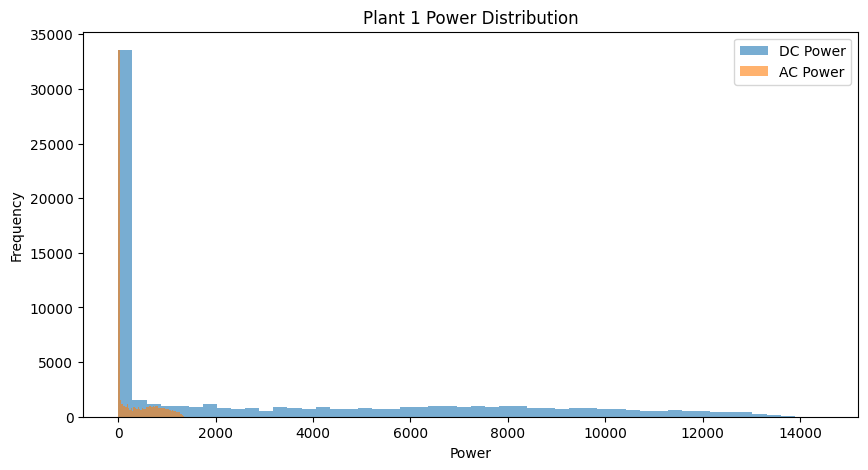

In [6]:
# Plot DC and AC power distributions for Plant 1
plt.figure(figsize=(10, 5))

plt.hist(
    plant1_generation["DC_POWER"],
    bins=50,
    alpha=0.6,
    label="DC Power"
)

plt.hist(
    plant1_generation["AC_POWER"],
    bins=50,
    alpha=0.6,
    label="AC Power"
)

plt.xlabel("Power")
plt.ylabel("Frequency")
plt.title("Plant 1 Power Distribution")
plt.legend()
plt.show()

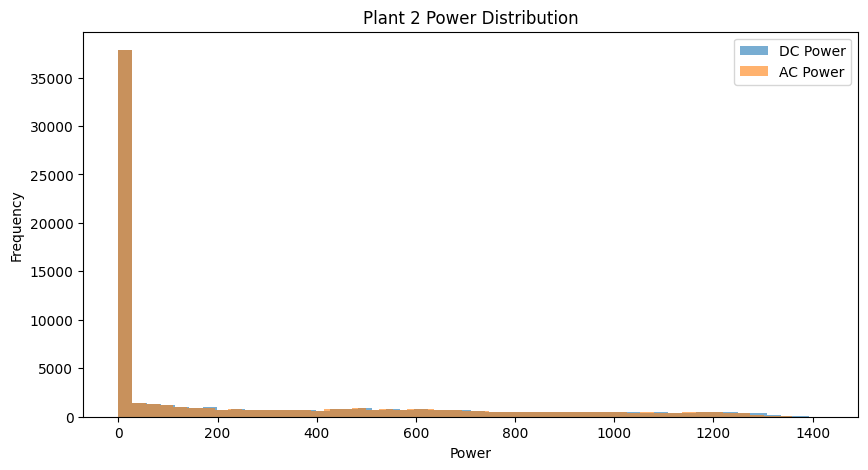

In [7]:
# Plot DC and AC power distributions for Plant 2
plt.figure(figsize=(10, 5))

plt.hist(
    plant2_generation["DC_POWER"],
    bins=50,
    alpha=0.6,
    label="DC Power"
)

plt.hist(
    plant2_generation["AC_POWER"],
    bins=50,
    alpha=0.6,
    label="AC Power"
)

plt.xlabel("Power")
plt.ylabel("Frequency")
plt.title("Plant 2 Power Distribution")
plt.legend()
plt.show()

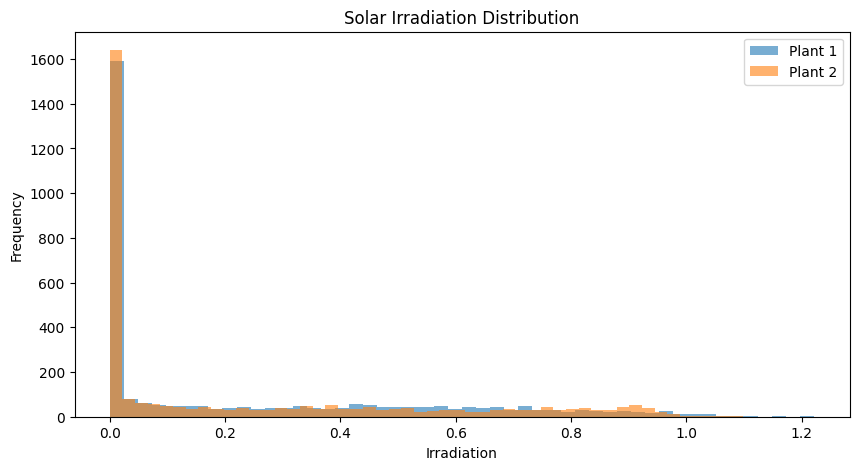

In [8]:
# Compare solar irradiation distributions
plt.figure(figsize=(10, 5))

plt.hist(
    plant1_weather["IRRADIATION"],
    bins=50,
    alpha=0.6,
    label="Plant 1"
)

plt.hist(
    plant2_weather["IRRADIATION"],
    bins=50,
    alpha=0.6,
    label="Plant 2"
)

plt.xlabel("Irradiation")
plt.ylabel("Frequency")
plt.title("Solar Irradiation Distribution")
plt.legend()
plt.show()

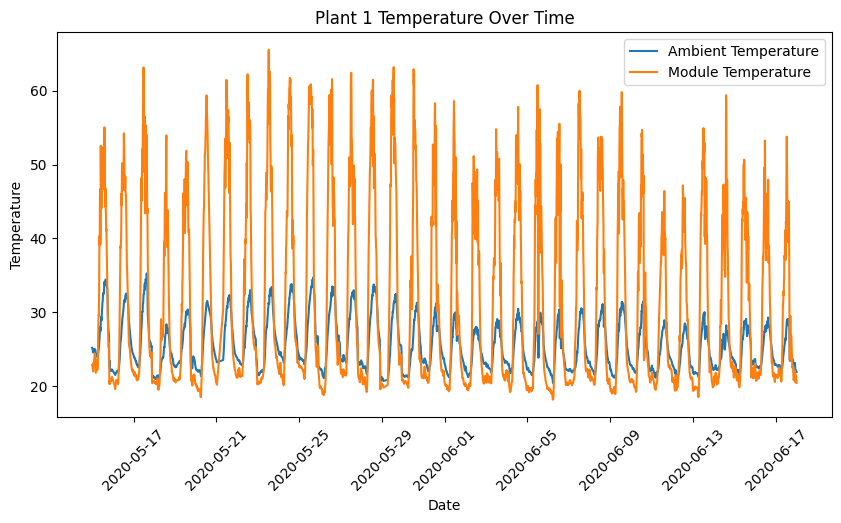

In [9]:
# Compare ambient and module temperature for Plant 1
plt.figure(figsize=(10, 5))

plt.plot(
    plant1_weather["DATE_TIME"],
    plant1_weather["AMBIENT_TEMPERATURE"],
    label="Ambient Temperature"
)

plt.plot(
    plant1_weather["DATE_TIME"],
    plant1_weather["MODULE_TEMPERATURE"],
    label="Module Temperature"
)

plt.xlabel("Date")
plt.ylabel("Temperature")
plt.title("Plant 1 Temperature Over Time")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [10]:
# Aggregate inverter-level AC power to plant-level power
plant1_power = (
    plant1_generation
    .groupby("DATE_TIME")["AC_POWER"]
    .sum()
    .reset_index()
)

plant2_power = (
    plant2_generation
    .groupby("DATE_TIME")["AC_POWER"]
    .sum()
    .reset_index()
)

In [11]:
# Merge plant-level power with weather observations
plant1_analysis = plant1_power.merge(
    plant1_weather[
        ["DATE_TIME", "IRRADIATION", "AMBIENT_TEMPERATURE",
         "MODULE_TEMPERATURE"]
    ],
    on="DATE_TIME",
    how="inner"
)

plant2_analysis = plant2_power.merge(
    plant2_weather[
        ["DATE_TIME", "IRRADIATION", "AMBIENT_TEMPERATURE",
         "MODULE_TEMPERATURE"]
    ],
    on="DATE_TIME",
    how="inner"
)

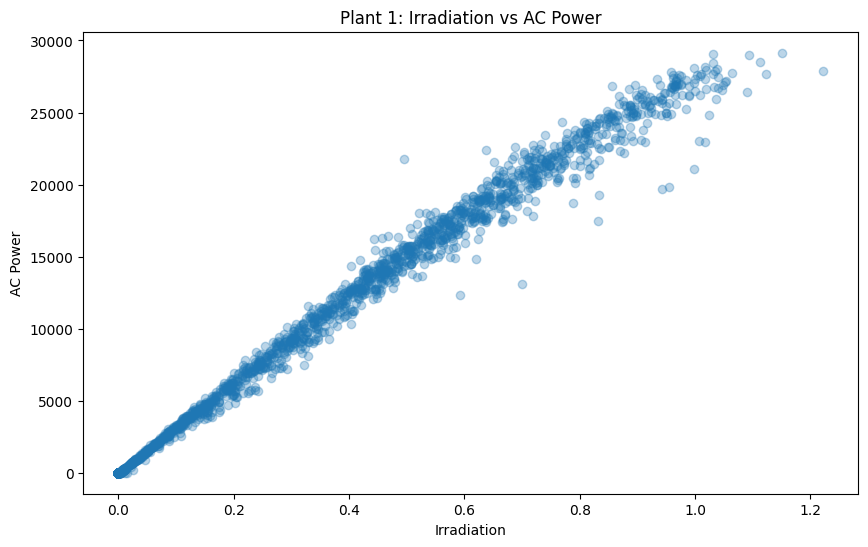

In [12]:
# Visualize relationship between irradiation and AC power
plt.figure(figsize=(10, 6))

plt.scatter(
    plant1_analysis["IRRADIATION"],
    plant1_analysis["AC_POWER"],
    alpha=0.3
)

plt.xlabel("Irradiation")
plt.ylabel("AC Power")
plt.title("Plant 1: Irradiation vs AC Power")
plt.show()

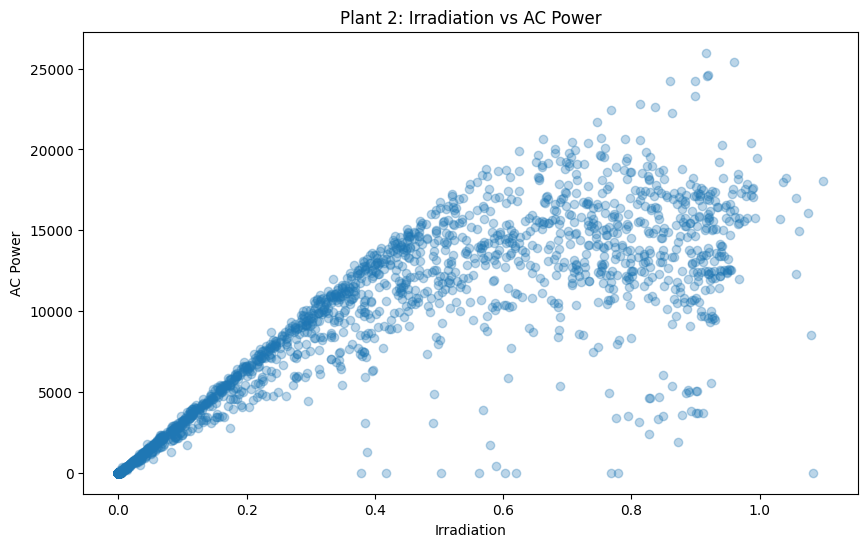

In [13]:
# Visualize Plant 2 irradiation and AC power relationship
plt.figure(figsize=(10, 6))

plt.scatter(
    plant2_analysis["IRRADIATION"],
    plant2_analysis["AC_POWER"],
    alpha=0.3
)

plt.xlabel("Irradiation")
plt.ylabel("AC Power")
plt.title("Plant 2: Irradiation vs AC Power")
plt.show()

Why this matters
Conceptually we expect:
Higher irradiation
       ↓
More solar energy
       ↓
Higher DC power
       ↓
Higher AC power

But we will let your actual dataset show the relationship, rather than assuming it.

In [14]:
# Step 14: Analyze average solar generation by hour of day
# This helps us understand the daily solar generation pattern.

# Create hour feature from timestamp
plant1_analysis["HOUR"] = plant1_analysis["DATE_TIME"].dt.hour
plant2_analysis["HOUR"] = plant2_analysis["DATE_TIME"].dt.hour

# Calculate average AC power for each hour
plant1_hourly = (
    plant1_analysis
    .groupby("HOUR")["AC_POWER"]
    .mean()
)

plant2_hourly = (
    plant2_analysis
    .groupby("HOUR")["AC_POWER"]
    .mean()
)

print("Plant 1 Average Power by Hour:")
print(plant1_hourly)

print("\nPlant 2 Average Power by Hour:")
print(plant2_hourly)

Plant 1 Average Power by Hour:
HOUR
0         0.000000
1         0.000000
2         0.000000
3         0.000000
4         0.000000
5         0.000000
6      1228.749808
7      5505.261588
8     10976.041995
9     15605.632800
10    18751.227633
11    21069.142779
12    20910.602669
13    19844.724600
14    17162.480458
15    13909.543751
16     8782.602444
17     3760.521850
18      454.019877
19        0.000000
20        0.000000
21        0.000000
22        0.000000
23        0.000000
Name: AC_POWER, dtype: float64

Plant 2 Average Power by Hour:
HOUR
0         0.000000
1         0.000000
2         0.000000
3         0.000000
4         0.000000
5         0.064055
6      1177.247780
7      4944.444366
8     10271.418824
9     13476.934340
10    13013.526908
11    13012.577966
12    13614.448468
13    12880.569497
14    13036.185537
15    12213.689090
16     8296.472309
17     3771.182547
18      639.962749
19        0.000000
20        0.000000
21        0.000000
22        0.000000
23 

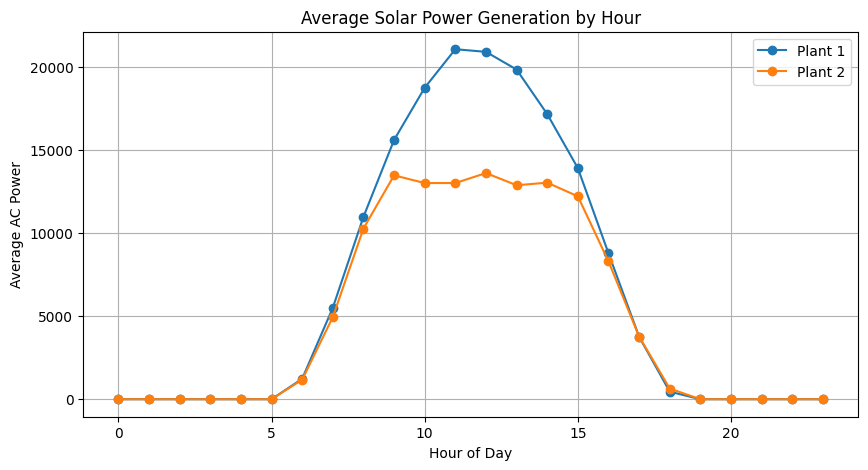

In [15]:
# Plot average solar generation throughout the day

plt.figure(figsize=(10, 5))

plt.plot(
    plant1_hourly.index,
    plant1_hourly.values,
    marker="o",
    label="Plant 1"
)

plt.plot(
    plant2_hourly.index,
    plant2_hourly.values,
    marker="o",
    label="Plant 2"
)

plt.xlabel("Hour of Day")
plt.ylabel("Average AC Power")
plt.title("Average Solar Power Generation by Hour")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
# Step 16: Calculate daily average AC power
# This helps identify daily generation patterns and unusual days.

plant1_analysis["DATE"] = plant1_analysis["DATE_TIME"].dt.date
plant2_analysis["DATE"] = plant2_analysis["DATE_TIME"].dt.date

plant1_daily = (
    plant1_analysis
    .groupby("DATE")["AC_POWER"]
    .mean()
)

plant2_daily = (
    plant2_analysis
    .groupby("DATE")["AC_POWER"]
    .mean()
)

print("Plant 1 Daily Power:")
print(plant1_daily.head())

print("\nPlant 2 Daily Power:")
print(plant2_daily.head())

Plant 1 Daily Power:
DATE
2020-05-15    5922.913542
2020-05-16    6458.634334
2020-05-17    6885.160305
2020-05-18    4905.934468
2020-05-19    5723.123560
Name: AC_POWER, dtype: float64

Plant 2 Daily Power:
DATE
2020-05-15    6857.239333
2020-05-16    5773.473547
2020-05-17    5670.760635
2020-05-18    5406.380888
2020-05-19    4563.733923
Name: AC_POWER, dtype: float64


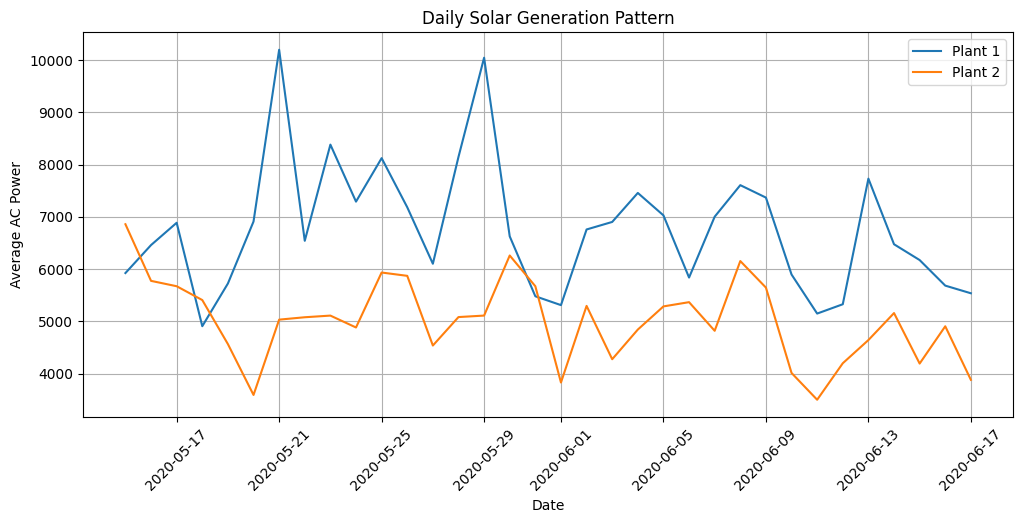

In [17]:
# Plot daily average generation

plt.figure(figsize=(12, 5))

plt.plot(
    plant1_daily.index,
    plant1_daily.values,
    label="Plant 1"
)

plt.plot(
    plant2_daily.index,
    plant2_daily.values,
    label="Plant 2"
)

plt.xlabel("Date")
plt.ylabel("Average AC Power")
plt.title("Daily Solar Generation Pattern")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

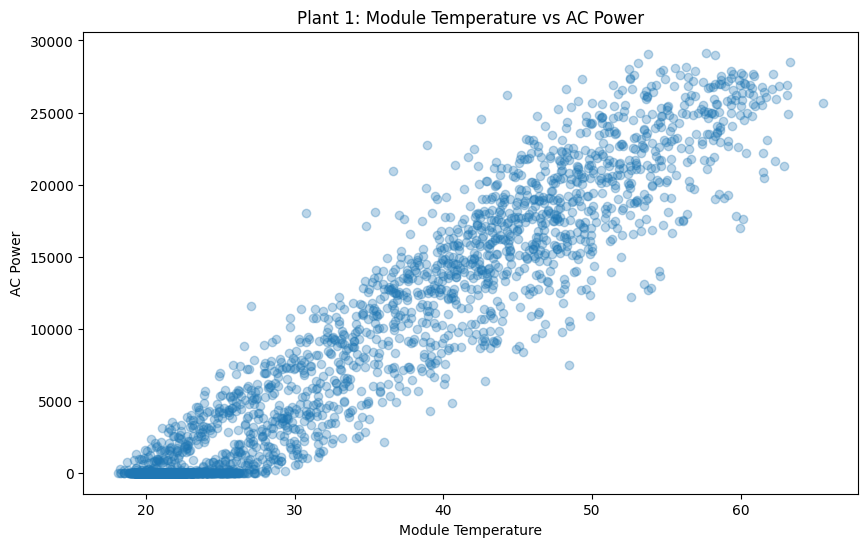

In [18]:
# Step 17: Analyze relationship between temperature and AC power

plt.figure(figsize=(10, 6))

plt.scatter(
    plant1_analysis["MODULE_TEMPERATURE"],
    plant1_analysis["AC_POWER"],
    alpha=0.3
)

plt.xlabel("Module Temperature")
plt.ylabel("AC Power")
plt.title("Plant 1: Module Temperature vs AC Power")
plt.show()

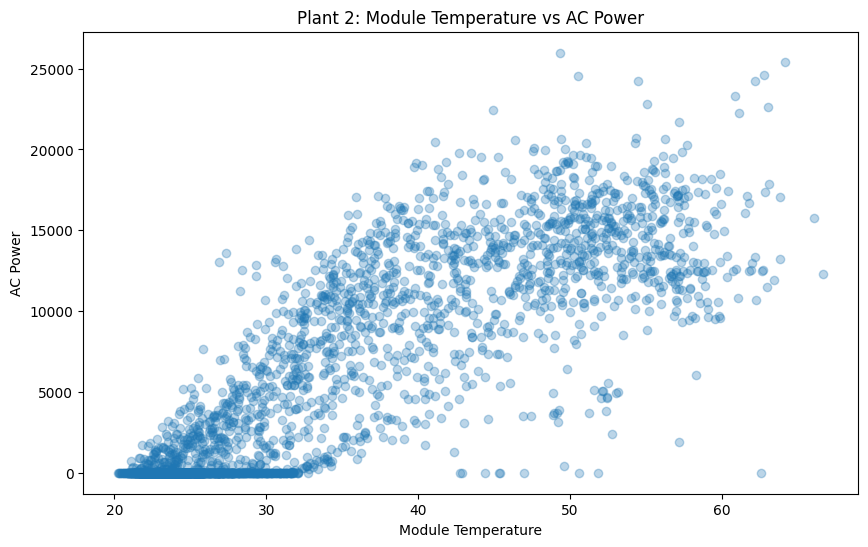

In [19]:
plt.figure(figsize=(10, 6))

plt.scatter(
    plant2_analysis["MODULE_TEMPERATURE"],
    plant2_analysis["AC_POWER"],
    alpha=0.3
)

plt.xlabel("Module Temperature")
plt.ylabel("AC Power")
plt.title("Plant 2: Module Temperature vs AC Power")
plt.show()

In [20]:
# Step 18: Calculate correlations between weather variables and AC power

plant1_corr = plant1_analysis[
    [
        "IRRADIATION",
        "AMBIENT_TEMPERATURE",
        "MODULE_TEMPERATURE",
        "AC_POWER"
    ]
].corr()

plant2_corr = plant2_analysis[
    [
        "IRRADIATION",
        "AMBIENT_TEMPERATURE",
        "MODULE_TEMPERATURE",
        "AC_POWER"
    ]
].corr()

print("Plant 1 Correlation:")
display(plant1_corr)

print("\nPlant 2 Correlation:")
display(plant2_corr)

Plant 1 Correlation:


,IRRADIATION,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,AC_POWER
IRRADIATION,1.000000,0.721839,0.961422,0.995864
AMBIENT_TEMPERATURE,0.721839,1.000000,0.853162,0.725879
MODULE_TEMPERATURE,0.961422,0.853162,1.000000,0.961011
AC_POWER,0.995864,0.725879,0.961011,1.000000



Plant 2 Correlation:


,IRRADIATION,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,AC_POWER
IRRADIATION,1.000000,0.667639,0.946886,0.911084
AMBIENT_TEMPERATURE,0.667639,1.000000,0.847273,0.648089
MODULE_TEMPERATURE,0.946886,0.847273,1.000000,0.871927
AC_POWER,0.911084,0.648089,0.871927,1.000000


In [21]:
# Step 19: Compare average inverter-level AC power
# This identifies differences in inverter performance.

plant1_inverter = (
    plant1_generation
    .groupby("SOURCE_KEY")["AC_POWER"]
    .mean()
    .sort_values(ascending=False)
)

plant2_inverter = (
    plant2_generation
    .groupby("SOURCE_KEY")["AC_POWER"]
    .mean()
    .sort_values(ascending=False)
)

print("Plant 1 Inverter Performance:")
print(plant1_inverter)

print("\nPlant 2 Inverter Performance:")
print(plant2_inverter)

Plant 1 Inverter Performance:
SOURCE_KEY
adLQvlD726eNBSB    319.693862
1IF53ai7Xc0U56Y    315.488026
3PZuoBAID5Wc2HD    314.967354
McdE0feGgRqW7Ca    314.046321
VHMLBKoKgIrUVDU    313.900096
iCRJl6heRkivqQ3    312.540320
uHbuxQJl8lW7ozc    312.467844
ZnxXDlPa8U1GXgE    312.346427
zVJPv84UY57bAof    311.676665
YxYtjZvoooNbGkE    310.930334
wCURE6d3bPkepu2    310.064044
pkci93gMrogZuBj    309.670213
rGa61gmuvPhdLxV    309.345658
WRmjgnKYAwPKWDb    308.575465
zBIq5rxdHJRwDNY    307.925344
sjndEbLyjtCKgGv    307.912265
ZoEaEvLYb1n2sOq    306.980623
z9Y9gH1T5YWrNuG    306.492026
7JYdWkrLSPkdwr4    306.385671
ih0vzX44oOqAx2f    302.962438
1BY6WEcLGh8j5v7    281.124073
bvBOhCH3iADSZry    276.778938
Name: AC_POWER, dtype: float64

Plant 2 Inverter Performance:
SOURCE_KEY
IQ2d7wF4YD8zU1Q    279.190055
Mx2yZCDsyf6DPfv    278.659553
xMbIugepa2P7lBB    274.504768
Qf4GUc1pJu5T6c6    272.536981
4UPUqMRk7TRMgml    271.576886
oZ35aAeoifZaQzV    270.871922
mqwcsP2rE7J0TFp    269.615561
NgDl19wMapZy17u 

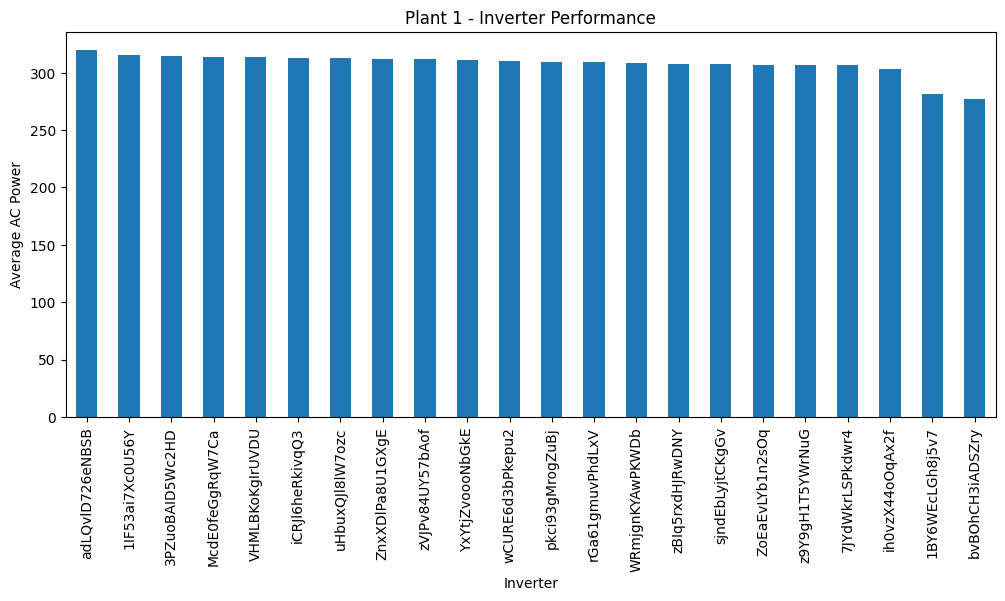

In [22]:
# Plot inverter-level average AC power

plt.figure(figsize=(12, 5))

plant1_inverter.plot(kind="bar")

plt.xlabel("Inverter")
plt.ylabel("Average AC Power")
plt.title("Plant 1 - Inverter Performance")
plt.xticks(rotation=90)
plt.show()

In [23]:
# Step 20: Identify inverters with relatively low average output

plant1_threshold = plant1_inverter.quantile(0.10)
plant2_threshold = plant2_inverter.quantile(0.10)

print("Plant 1 Low-Performance Threshold:", plant1_threshold)
print("Plant 2 Low-Performance Threshold:", plant2_threshold)

print("\nPotentially Low-Performing Plant 1 Inverters:")
print(plant1_inverter[plant1_inverter <= plant1_threshold])

print("\nPotentially Low-Performing Plant 2 Inverters:")
print(plant2_inverter[plant2_inverter <= plant2_threshold])

Plant 1 Low-Performance Threshold: 303.30476113601634
Plant 2 Low-Performance Threshold: 193.34787154363994

Potentially Low-Performing Plant 1 Inverters:
SOURCE_KEY
ih0vzX44oOqAx2f    302.962438
1BY6WEcLGh8j5v7    281.124073
bvBOhCH3iADSZry    276.778938
Name: AC_POWER, dtype: float64

Potentially Low-Performing Plant 2 Inverters:
SOURCE_KEY
LYwnQax7tkwH5Cb    192.090443
Et9kgGMDl729KT4    184.230269
Quc1TzYxW2pYoWX    169.644735
Name: AC_POWER, dtype: float64


In [24]:
# Final check for missing values in the analysis datasets

for name, df in {
    "Plant 1 Analysis": plant1_analysis,
    "Plant 2 Analysis": plant2_analysis
}.items():

    print(name)
    print(df.isnull().sum())
    print()

Plant 1 Analysis
DATE_TIME              0
AC_POWER               0
IRRADIATION            0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
HOUR                   0
DATE                   0
dtype: int64

Plant 2 Analysis
DATE_TIME              0
AC_POWER               0
IRRADIATION            0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
HOUR                   0
DATE                   0
dtype: int64



In [25]:
# Check correlations between numerical variables and AC power

print("Plant 1 Correlation:")
display(
    plant1_analysis[
        ["IRRADIATION", "AMBIENT_TEMPERATURE",
         "MODULE_TEMPERATURE", "AC_POWER"]
    ].corr()
)

print("\nPlant 2 Correlation:")
display(
    plant2_analysis[
        ["IRRADIATION", "AMBIENT_TEMPERATURE",
         "MODULE_TEMPERATURE", "AC_POWER"]
    ].corr()
)

Plant 1 Correlation:


,IRRADIATION,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,AC_POWER
IRRADIATION,1.000000,0.721839,0.961422,0.995864
AMBIENT_TEMPERATURE,0.721839,1.000000,0.853162,0.725879
MODULE_TEMPERATURE,0.961422,0.853162,1.000000,0.961011
AC_POWER,0.995864,0.725879,0.961011,1.000000



Plant 2 Correlation:


,IRRADIATION,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,AC_POWER
IRRADIATION,1.000000,0.667639,0.946886,0.911084
AMBIENT_TEMPERATURE,0.667639,1.000000,0.847273,0.648089
MODULE_TEMPERATURE,0.946886,0.847273,1.000000,0.871927
AC_POWER,0.911084,0.648089,0.871927,1.000000


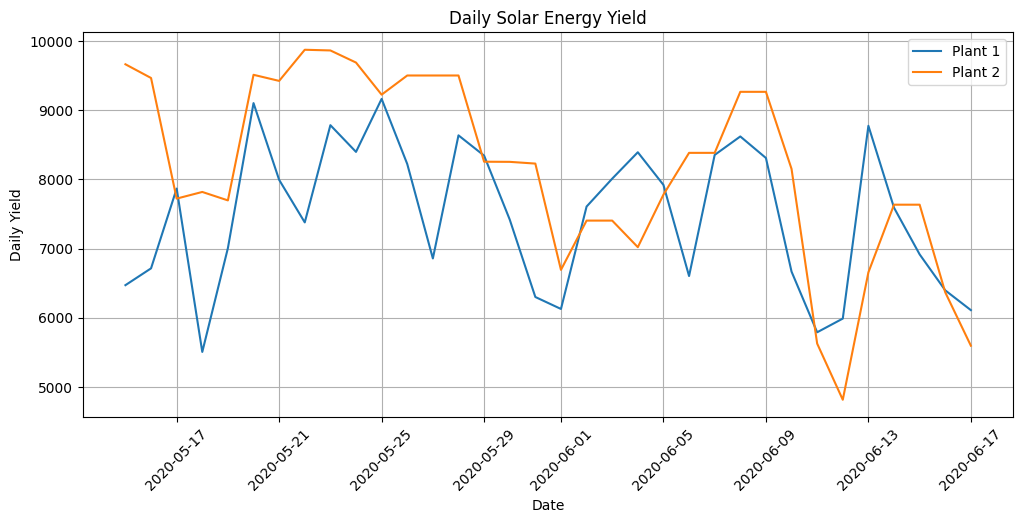

In [26]:
# Analyze daily energy yield over time

plant1_yield = (
    plant1_generation
    .groupby(plant1_generation["DATE_TIME"].dt.date)["DAILY_YIELD"]
    .max()
)

plant2_yield = (
    plant2_generation
    .groupby(plant2_generation["DATE_TIME"].dt.date)["DAILY_YIELD"]
    .max()
)

plt.figure(figsize=(12, 5))

plt.plot(plant1_yield.index, plant1_yield.values, label="Plant 1")
plt.plot(plant2_yield.index, plant2_yield.values, label="Plant 2")

plt.xlabel("Date")
plt.ylabel("Daily Yield")
plt.title("Daily Solar Energy Yield")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()